In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n = 200

# Create the initial dataset
data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

# Introduce missing values
missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

# Introduce outliers
data["order_value"][5] = 95000
data["order_value"][88] = 87000

# Create DataFrame
df = pd.DataFrame(data)

# Initial check
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [2]:
# Task 2:Summarize & Visualize

# 1. Print shape
print("DataFrame Shape:", df.shape)

# 2. Display data types
print("\nData Types:\n", df.dtypes)

# 3. Count missing values per column
missing_count = df.isnull().sum()
print("\nMissing Values Count:\n", missing_count)

# 4. Calculate percentage of missing values (rounded to 2 decimal places)
missing_percentage = (missing_count / len(df)) * 100
print("\nPercentage of Missing Values:\n", missing_percentage.round(2))

DataFrame Shape: (200, 6)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Percentage of Missing Values:
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


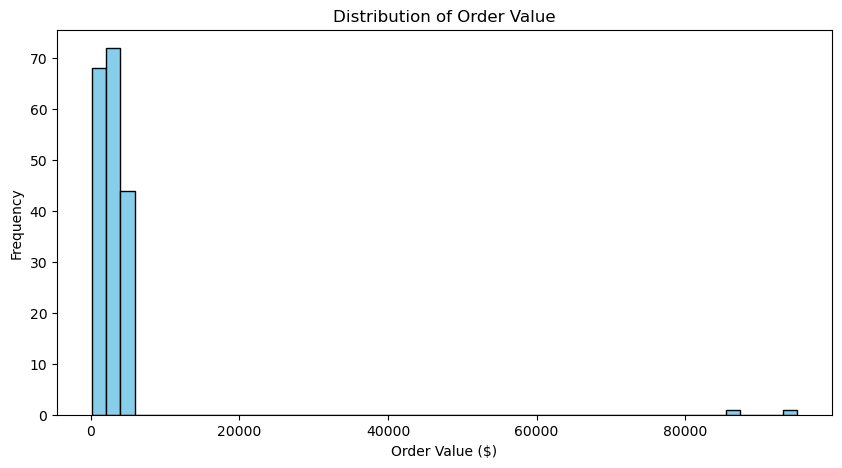

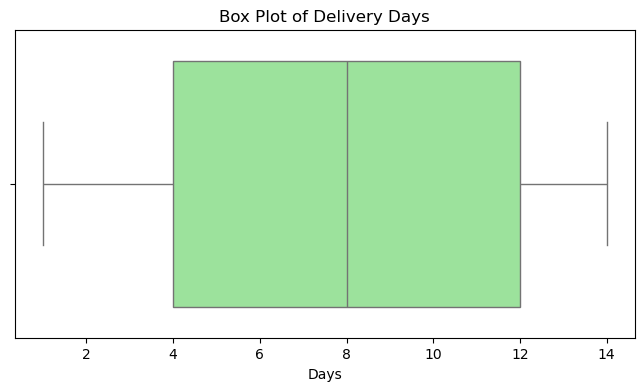

In [3]:
# Histogram for order_value
plt.figure(figsize=(10, 5))
plt.hist(df['order_value'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Order Value')
plt.xlabel('Order Value ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot for delivery_days
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Days')
plt.show()

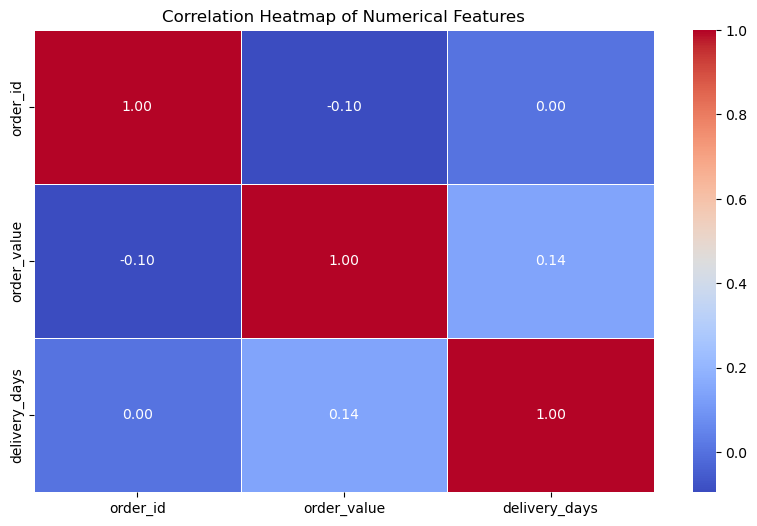

In [4]:
# Task 3 — Correlation Analysis

# 1. Compute correlation matrix (only for numerical columns)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()